100%|██████████| 1.94M/1.94M [00:00<00:00, 120MB/s]

Extracting files...


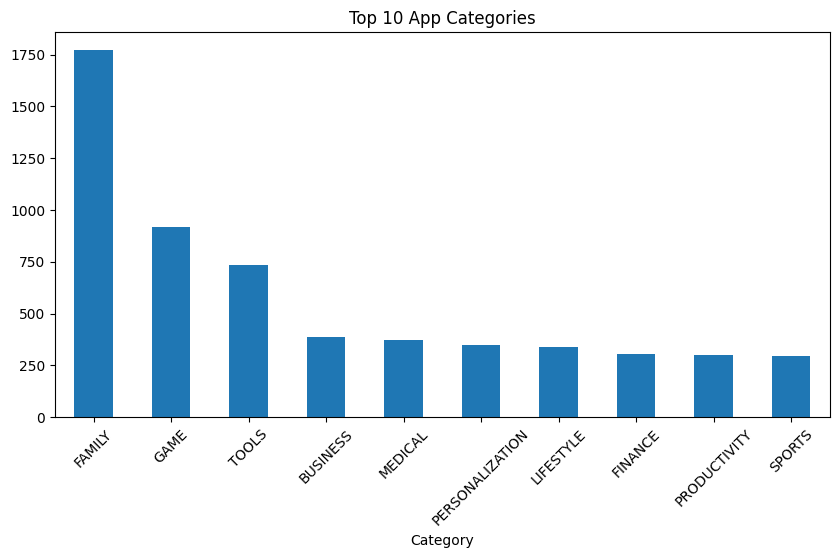

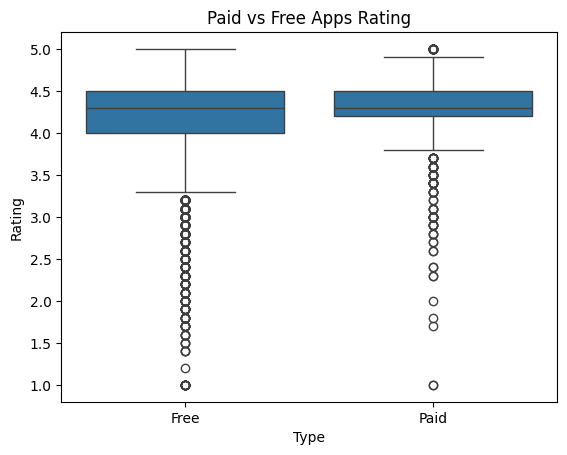

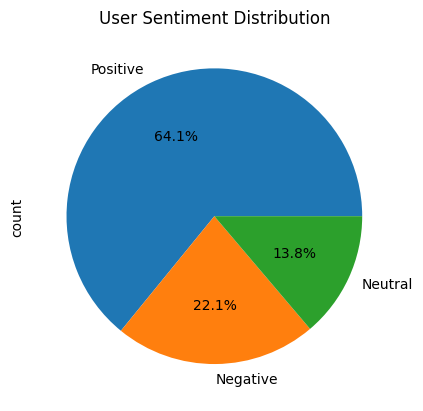

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install -q kagglehub
import kagglehub
path = kagglehub.dataset_download("lava18/google-play-store-apps")

apps = pd.read_csv(f'{path}/googleplaystore.csv')
reviews = pd.read_csv(f'{path}/googleplaystore_user_reviews.csv')

apps = apps.drop_duplicates(subset='App')
apps = apps[apps['Android Ver'].astype(str) != 'Varies with device']

apps['Size'] = apps['Size'].astype(str).str.replace('M','').str.replace('k','').str.replace('Varies with device','0')
apps['Size'] = pd.to_numeric(apps['Size'], errors='coerce')

apps['Installs'] = apps['Installs'].astype(str).str.replace('+','').str.replace(',','')
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

apps['Price'] = apps['Price'].astype(str).str.replace('$','')
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())
apps = apps.dropna(subset=['Installs','Price'])

plt.figure(figsize=(10,5))
apps['Category'].value_counts()[:10].plot(kind='bar')
plt.title('Top 10 App Categories')
plt.xticks(rotation=45)
plt.show()

sns.boxplot(x='Type', y='Rating', data=apps)
plt.title('Paid vs Free Apps Rating')
plt.show()

reviews = reviews.dropna(subset=['Sentiment'])
reviews['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('User Sentiment Distribution')
plt.show()